# Notebook 01 - Linear Regression Model

This notebook follows the [Linear Regression from Scratch in Python](https://www.youtube.com/watch?v=VmbA0pi2cRQ) video. 
<br>Data is sourced from Kaggle.

## 1. Package and data import

In [71]:
# Package import
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

# Download latest version of data from Kaggle API
kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression", output_dir='./data')

'./data'

In [72]:
# Import data into Juputer file
df = pd.read_csv('data/Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## 2. Defining variables and functions

## 2.1 Defining variables

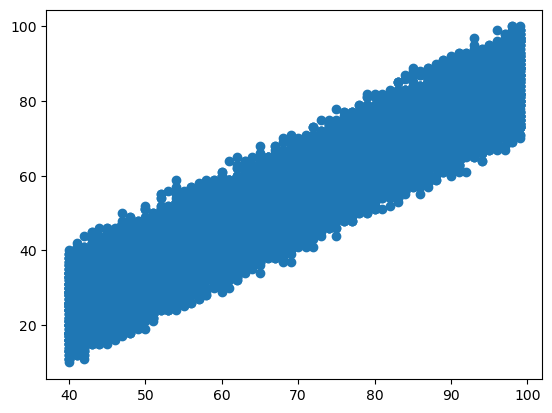

In [73]:
# Variables of interest: 
performance_index = df['Performance Index']
prev_scores = df['Previous Scores']

points = df[['Previous Scores', 'Performance Index']]
# plt.scatter(hours_studied, performance_index)
# plt.scatter(sleep_hours, performance_index)

plt.scatter(points['Previous Scores'], points['Performance Index'])

### 2.1.1 Data normalization

## 2.2 Defining functions

In [97]:
# Loss function
def loss_function(m, b, points):
    total_error = 0
    for i in range(len(points)):
        x = points['Previous Scores'].iloc[i]
        y = points['Performance Index'].iloc[i]
        total_error += (y - (m * x + b))**2
    total_error = total_error / float(len(points))
    return total_error

# gradient descent function
# Pass in: current m value, current b value, df with previous scores and performance indices.
# Return: new m, new b
# Purpose: Return new m and b values in the direction of steepest descent and multiplied by the learning rate.
def new_gradient(m_now, b_now, points, L):
    # inital values
    m_gradient = 0
    b_gradient = 0

    n = len(points)

    for i in range(n):
        x_i = points.iloc[i, 0]
        y_i = points.iloc[i, 1]

        # Summation from error function
        m_gradient += -2/n * x_i * (y_i - (m_now * x_i + b_now)) # change in the m value (before L)
        b_gradient += -2/n * (y_i - (m_now * x_i + b_now)) # change in the b value (before L)
    
    m = m_now - m_gradient * L
    b = b_now - b_gradient * L

    return m, b

In [98]:
points.iloc[2, 0]

np.int64(51)

# 3. Applying regression functions

In [99]:
print(df.describe())

       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.000000   
50%         5.000000        69.000000      7.000000   
75%         7.000000        85.000000      8.000000   
max         9.000000        99.000000      9.000000   

       Sample Question Papers Practiced  Performance Index  
count                      10000.000000       10000.000000  
mean                           4.583300          55.224800  
std                            2.867348          19.212558  
min                            0.000000          10.000000  
25%                            2.000000          40.000000  
50%                            5.000000          55.000000  
75%                            7.000000          71.000000  
max             

In [100]:
# Defining starting and iteration values

m = 0
b = 0
L = 0.00013   #'step' size
epochs = 2000   #number of iterations

# best so far: L = 0.005, epochs = 300

# Lists of 
m_list = []
b_list = []

for i in range(epochs):
    if i % 50 == 0:
        print(f'epoch: {i}')
        print(m, b)
    m, b = new_gradient(m, b, points, L)
    
    m_list.append(m)
    b_list.append(b)
estimators = pd.DataFrame({"m": m_list, 
                           "b": b_list})
estimators.reset_index(drop=True, inplace=True)

error = loss_function(m, b, points)

print("final m:", round(m, 3), "b:", round(b, 3))
print("error:", error)

plt.scatter(prev_scores, performance_index)
plt.plot(list(range(0, 99)), [m * x + b for x in range(0, 99)], color='red')



epoch: 0
0 0
epoch: 50
0.8080619836004356 -0.0006365890440775364
epoch: 100
0.8082189268032468 -0.01221517528424203
epoch: 150
0.8083757503063731 -0.02378493060277354
epoch: 200
0.8085324542011088 -0.03534586173496554
epoch: 250
0.8086890385786784 -0.046897975410974645
epoch: 300
0.808845503530237 -0.058441278355824286
epoch: 350
0.8090018491468701 -0.06997577728940883
epoch: 400
0.8091580755195941 -0.08150147892649748
epoch: 450
0.8093141827393552 -0.09301838997673804
epoch: 500
0.8094701708970309 -0.10452651714466091
epoch: 550
0.8096260400834291 -0.11602586712968295
epoch: 600
0.8097817903892887 -0.1275164466261115


KeyboardInterrupt: 

In [103]:
print(-0.01221517528424203 + 0.01221517528424203)

0.0


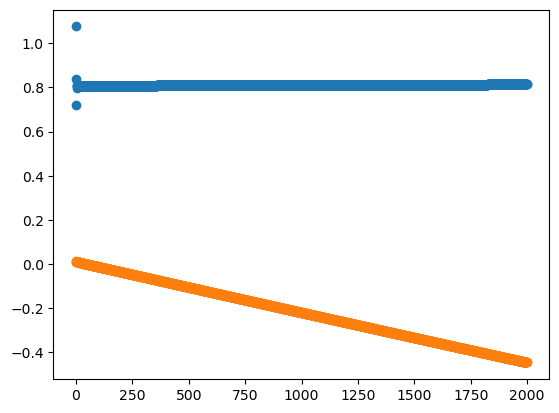

In [88]:
estimators

plt.scatter(estimators.index, estimators['m'])
plt.scatter(estimators.index, estimators['b'])

In [78]:
# testing

x = 0

for i in range(0,9):
    x += 1
    print(x)

x = 0

for i in range(0,9):
    x =+ 1
    print(x)

1
2
3
4
5
6
7
8
9
1
1
1
1
1
1
1
1
1
